# Diabetes Risk Machine Learning Prediction
### Binary Classification of Diabetes Risk using Logistic Regression and Random Forest Models

Authored by Leo Littlewood  

## 1) Imports and Configuration

In [1]:
# Fix numpy/matplotlib version conflict, then import packages
import subprocess, sys

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '--upgrade',
    'numpy', 'matplotlib', 'pandas', 'scikit-learn',
    'imbalanced-learn', 'shap', 'seaborn',
    '--quiet'
])

print('✓ Packages upgraded')


✓ Packages upgraded


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

# Ignore benign convergence and deprecation warnings from sklearn and shap 
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
print("All imports successful")


All imports successful


/Users/sovicheatat/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Configuration
RANDOM_SEED  = 42     # fixed the seed for all stochastic steps
TEST_SIZE    = 0.20   # set train-test split to 80/20 
N_CV_FOLDS   = 5      # stratified k-fold
N_SEEDS      = 10     # number of seeds for stability analysis

os.makedirs("outputs", exist_ok=True)

# set colour palette to be Colourblind-safe 
PALETTE = {
    "primary":   "#2C7BB6",
    "secondary": "#D7191C",
    "neutral":   "#636363",
    "highlight": "#9F0D91",
    "pos":       "#1A9641",
    "neg":       "#D73027",
}

# Shared plot style
plt.rcParams.update({
    "font.family":         "DejaVu Sans",
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.grid":           True,
    "grid.alpha":          0.3,
    "figure.dpi":          120,
})
print("Configuration set")


Configuration set


## 2) Load Dataset

In [4]:
# Load dataset from personal GitHub for reproducibility
CSV_PATH = "https://raw.githubusercontent.com/leosijunltw/HDS_MM_LEOLITTLEWOOD_2604/main/diabetes_binary_health_indicators_BRFSS2021.csv"
df_raw = pd.read_csv(CSV_PATH)
print(f"Loaded — {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols")
df_raw.head()


Loaded — 236,378 rows × 22 cols


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0,1.0,1,15.0,1.0,0.0,0.0,0,1,...,1,0.0,5.0,10.0,20.0,0.0,0,11,4.0,5.0
1,1.0,1,0.0,1,28.0,0.0,0.0,1.0,0,1,...,1,0.0,2.0,0.0,0.0,0.0,0,11,4.0,3.0
2,1.0,1,1.0,1,33.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,10.0,0.0,0.0,0,9,4.0,7.0
3,1.0,0,1.0,1,29.0,0.0,1.0,1.0,1,1,...,1,0.0,5.0,0.0,30.0,1.0,1,12,3.0,4.0
4,0.0,0,0.0,1,24.0,1.0,0.0,0.0,0,0,...,1,0.0,3.0,0.0,0.0,1.0,1,13,5.0,6.0


## 3) Exploratory Analysis

In [5]:
print("Basic information:")
print(f"Shape          : {df_raw.shape}")
print(f"Missing values : {df_raw.isnull().sum().sum()}")
print(f"Duplicate rows : {df_raw.duplicated().sum()}")
print(f"\nTarget distribution:")
print(df_raw["Diabetes_binary"].value_counts(normalize=True).round(3))


Basic information:
Shape          : (236378, 22)
Missing values : 0
Duplicate rows : 13135

Target distribution:
Diabetes_binary
0.0    0.858
1.0    0.142
Name: proportion, dtype: float64


In [6]:
df_raw.describe().round(2)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,236378.00,236378.00,236378.00,236378.00,236378.00,236378.00,236378.00,236378.00,236378.00,236378.00,...,236378.00,236378.00,236378.00,236378.00,236378.00,236378.00,236378.00,236378.00,236378.00,236378.00
mean,0.14,0.42,0.40,0.96,28.95,0.41,0.04,0.09,0.78,0.62,...,0.96,0.06,2.48,3.94,3.75,0.15,0.48,7.86,5.14,6.93
std,0.35,0.49,0.49,0.19,6.55,0.49,0.19,0.28,0.41,0.49,...,0.19,0.24,1.03,7.89,8.25,0.36,0.50,3.24,0.95,2.38
min,0.00,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,5.00,4.00,5.00
50%,0.00,0.00,0.00,1.00,28.00,0.00,0.00,0.00,1.00,1.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00
75%,0.00,1.00,1.00,1.00,32.00,1.00,0.00,0.00,1.00,1.00,...,1.00,0.00,3.00,4.00,2.00,0.00,1.00,10.00,6.00,9.00
max,1.00,1.00,1.00,1.00,99.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,11.00


## 4) Feature Engineering

In [7]:
# The full original set of BRFSS features (21 total):
FEATURES = [
    "BMI", "Age", "HighBP", "HighChol", "HeartDiseaseorAttack",
    "Smoker", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump",
    "GenHlth", "DiffWalk", "Stroke", "Sex", "Income", "Education",
    "MentHlth", "PhysHlth", "CholCheck", "AnyHealthcare", "NoDocbcCost"
]

# rename features for clarity to the reader in future generated outputs
RENAME_MAP = {
    "HeartDiseaseorAttack": "HeartIssues",
    "HvyAlcoholConsump":    "HeavyAlcohol",
    "HighBP":               "BloodPressure",
    "HighChol":             "Cholesterol",
    "PhysActivity":         "PhysicalActivity",
    "DiffWalk":             "DifficultyWalking",
    "GenHlth":              "GeneralHealth",
    "MentHlth":             "MentalHealthDays",
    "PhysHlth":             "PhysicalHealthDays",
    "CholCheck":            "CholesterolCheck",
    "AnyHealthcare":        "HasHealthcare",
    "NoDocbcCost":          "CostBarrierToDoc",
}

df = df_raw[FEATURES + ["Diabetes_binary"]].copy().dropna().drop_duplicates()
df = df.rename(columns=RENAME_MAP)
FEATURES_RENAMED = [RENAME_MAP.get(f, f) for f in FEATURES]
TARGET = "Diabetes_binary"


# Create engineered features:

# BMI × Age: captures the joint effect of high BMI and older age on diabetes risk
df["BMI_x_Age"] = df["BMI"] * df["Age"]

# Cardio Risk Score: captures the cumulative burden of 4 cardiometabolic risks (blood pressure, cholesterol, heart issues, and stroke) 
df["CardioRisk_Score"] = (
    df["BloodPressure"] + df["Cholesterol"] + df["HeartIssues"] + df["Stroke"]
)

# Diet Score: joint measure of fruit and vegetable consumption
df["DietScore"] = df["Fruits"] + df["Veggies"]

# Lifestyle Risk Score: Adverse lifestyle count of smoker, lack of physical activity, and heavy alcohol (0–3)
df["LifestyleRisk_Score"] = (
    df["Smoker"] + (1 - df["PhysicalActivity"]) + df["HeavyAlcohol"]
)

# Poor Health Days: Total self-reported mental and physical health days in the past 30 days
df["PoorHealth_Days"] = df["MentalHealthDays"] + df["PhysicalHealthDays"]

# BMI Inactive (a key insulin-resistance proxy): High BMI and physically inactive
df["BMI_Inactive"] = df["BMI"] * (1 - df["PhysicalActivity"])

ENGINEERED = [
    "BMI_x_Age", "CardioRisk_Score", "DietScore",
    "LifestyleRisk_Score", "PoorHealth_Days", "BMI_Inactive"
]
# Overwrite FEATURES_RENAMED so downstream references include engineered features
ALL_FEATURES   = FEATURES_RENAMED + ENGINEERED
FEATURES_RENAMED = ALL_FEATURES

X = df[FEATURES_RENAMED]
y = df[TARGET].astype(int)

print(f"  Clean dataset  : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"  Original (BRFSS): {len(FEATURES)}")
print(f"  Engineered      : {len(ENGINEERED)}  ({', '.join(ENGINEERED)})")
print(f"  Class balance   : No diabetes {(y==0).mean():.1%}  |  Diabetes {(y==1).mean():.1%}")


  Clean dataset  : 223,243 rows × 27 features
  Original (BRFSS): 21
  Engineered      : 6  (BMI_x_Age, CardioRisk_Score, DietScore, LifestyleRisk_Score, PoorHealth_Days, BMI_Inactive)
  Class balance   : No diabetes 85.0%  |  Diabetes 15.0%


## 5) Train/Test Split

In [8]:
# perform stratified split to maintain approximately 85:15 class ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_SEED,
    stratify     = y          # maintain class ratio in both splits
)
print(f"  Train : {X_train.shape[0]:,} rows")
print(f"  Test  : {X_test.shape[0]:,} rows")


  Train : 178,594 rows
  Test  : 44,649 rows


## 6) Dataset Preprocessing and Model Setup

In [9]:
# ImbPipeline (as opposed to sklearn's Pipeline) is required, as SMOTE is a resampler (and not a transformer) 
# ImbPipeline applies it only at fit time, which prevents data leakage
# Scaling is implemented to the Logistic Regression, as it is gradient-based, and so scale-sensitive, but not Random Forest, as tree splits are scale-invariant

# Logistic Regression process: perform StandardScaler, then SMOTE, then Logistic Regression
lr_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote",  SMOTE(random_state=RANDOM_SEED)),
    ("lr",     LogisticRegression(
        max_iter     = 1000,           # raised from default 100 to ensure convergence
        random_state = RANDOM_SEED,
        solver       = "lbfgs"         # overridden to liblinear in grid search (supports L1)
    ))
])

# Random Forest process: perform SMOTE, then Random Forest  
rf_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_SEED)),
    ("rf",    RandomForestClassifier(
        n_estimators = 300,            # baseline; tuned in section 8
        random_state = RANDOM_SEED,
        n_jobs       = -1
    ))
])

print("Pipelines successfully created")


Pipelines successfully created


## 7) Baseline Cross-Validation

In [10]:
# perform the baseline 5-fold stratified CV on both the Logistic Regression and Random Forest models, without tuning
# this is scored by AUC-ROC
cv = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

print(f"── {N_CV_FOLDS}-fold stratified cross-validation (baseline, no tuning) ──────────────")
for name, pipe in [("Logistic Regression", lr_pipeline), ("Random Forest", rf_pipeline)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    print(f"  {name:22s} | AUC-ROC = {scores.mean():.4f} ± {scores.std():.4f}")


── 5-fold stratified cross-validation (baseline, no tuning) ──────────────


/Users/sovicheatat/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sovicheatat/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sovicheatat/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sovicheatat/Lib

  Logistic Regression    | AUC-ROC = 0.8074 ± 0.0025


/Users/sovicheatat/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sovicheatat/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sovicheatat/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sovicheatat/Lib

  Random Forest          | AUC-ROC = 0.7754 ± 0.0018


## 8) Hyperparameter Tuning

In [11]:
print("── Logistic Regression — GridSearchCV ────────────────────────────────────")

# C spans 6 orders of magnitude to detect if the optimum lies at the extremes
# liblinear solver was selected, due to it supporting both L1 and L2 penalties
lr_param_grid = {
    "lr__C":       [0.001, 0.01, 0.1, 1, 10, 100],
    "lr__penalty": ["l1", "l2"],
    "lr__solver":  ["liblinear"],
}

lr_search = GridSearchCV(
    lr_pipeline, lr_param_grid,
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=0
)
lr_search.fit(X_train, y_train)
best_lr = lr_search.best_estimator_
print(f"  Best params : {lr_search.best_params_}")
print(f"  Best CV AUC : {lr_search.best_score_:.4f}")


── Logistic Regression — GridSearchCV ────────────────────────────────────


/Users/sovicheatat/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sovicheatat/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sovicheatat/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sovicheatat/Lib

  Best params : {'lr__C': 0.01, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}
  Best CV AUC : 0.8074


In [12]:
print("── Random Forest — RandomizedSearchCV ────────────────────────────────────")

# RandomizedSearch (n_iter=20) is preferable over exhaustive grid (96 combinations), due to the high parameter space and fit cost
rf_param_dist = {
    "rf__n_estimators":   [100, 200, 300, 500],
    "rf__max_depth":      [None, 10, 20, 30],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features":   ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_param_dist,
    n_iter        = 20,
    cv            = cv,
    scoring       = "roc_auc",
    random_state  = RANDOM_SEED,
    n_jobs        = -1,
    verbose       = 0,
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print(f"  Best params : {rf_search.best_params_}")
print(f"  Best CV AUC : {rf_search.best_score_:.4f}")


── Random Forest — RandomizedSearchCV ────────────────────────────────────


/Users/sovicheatat/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sovicheatat/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sovicheatat/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sovicheatat/Lib

  Best params : {'rf__n_estimators': 200, 'rf__min_samples_leaf': 4, 'rf__max_features': 'log2', 'rf__max_depth': 20}
  Best CV AUC : 0.8016


## 9) Test Set Evaluation

In [13]:
results = {}
for name, model in [("Logistic Regression", best_lr), ("Random Forest", best_rf)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "y_pred":    y_pred,
        "y_prob":    y_prob,
        "auc_roc":   roc_auc_score(y_test, y_prob),
        "f1":        f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall":    recall_score(y_test, y_pred),
        "accuracy":  accuracy_score(y_test, y_pred),
        "avg_prec":  average_precision_score(y_test, y_prob),
    }

summary = pd.DataFrame({
    "Metric": ["AUC-ROC","F1 Score","Precision","Recall","Accuracy","Avg Precision"],
    "Logistic Regression": [
        f"{results['Logistic Regression']['auc_roc']:.4f}",
        f"{results['Logistic Regression']['f1']:.4f}",
        f"{results['Logistic Regression']['precision']:.4f}",
        f"{results['Logistic Regression']['recall']:.4f}",
        f"{results['Logistic Regression']['accuracy']:.4f}",
        f"{results['Logistic Regression']['avg_prec']:.4f}",
    ],
    "Random Forest": [
        f"{results['Random Forest']['auc_roc']:.4f}",
        f"{results['Random Forest']['f1']:.4f}",
        f"{results['Random Forest']['precision']:.4f}",
        f"{results['Random Forest']['recall']:.4f}",
        f"{results['Random Forest']['accuracy']:.4f}",
        f"{results['Random Forest']['avg_prec']:.4f}",
    ],
}).set_index("Metric")

summary


,Logistic Regression,Random Forest
Metric,,
AUC-ROC,0.8067,0.8022
F1 Score,0.4448,0.3286
Precision,0.3164,0.4689
Recall,0.7486,0.2529
Accuracy,0.7204,0.8454
Avg Precision,0.4022,0.3967


## 10) Test of Stability over Random Seeds

In [14]:
stability = {"Logistic Regression": [], "Random Forest": []}

for seed in range(N_SEEDS):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=seed, stratify=y
    )
    for name, base_pipe, best_params in [
        ("Logistic Regression", lr_pipeline, lr_search.best_params_),
        ("Random Forest",       rf_pipeline, rf_search.best_params_),
    ]:
        pipe_copy = base_pipe.set_params(**best_params)
        pipe_copy.fit(Xtr, ytr)
        auc = roc_auc_score(yte, pipe_copy.predict_proba(Xte)[:, 1])
        stability[name].append(auc)

print(f"── Stability across {N_SEEDS} seeds ─────────────────────────────────────────")
for name, aucs in stability.items():
    print(f"  {name:22s} | AUC = {np.mean(aucs):.4f} ± {np.std(aucs):.4f}  "
          f"[{np.min(aucs):.4f} – {np.max(aucs):.4f}]")


── Stability across 10 seeds ─────────────────────────────────────────
  Logistic Regression    | AUC = 0.8075 ± 0.0020  [0.8042 – 0.8108]
  Random Forest          | AUC = 0.8028 ± 0.0021  [0.7989 – 0.8062]


In [ ]:
from scipy.stats import ttest_rel, wilcoxon

# perform paired t-test on 10-seed AUC-ROC distributions (LR vs RF)
# also calculate Wilcoxon statistic to report alongside to act as a non-parametric check.
lr_aucs = np.array(stability["Logistic Regression"])
rf_aucs = np.array(stability["Random Forest"])
differences = lr_aucs - rf_aucs

t_stat, t_pval = ttest_rel(lr_aucs, rf_aucs)
w_stat, w_pval = wilcoxon(lr_aucs, rf_aucs)

print(f"── Paired statistical comparison (n={N_SEEDS} seeds) ──────────────────────")
print(f"  Mean difference (LR - RF) : {differences.mean():+.4f}")
print(f"  SD of paired differences  :  {differences.std(ddof=1):.4f}")
print(f"  Paired t-test             : t = {t_stat:.3f},  p = {t_pval:.2e}")
print(f"  Wilcoxon signed-rank test : W = {w_stat:.1f},  p = {w_pval:.2e}")


── Paired statistical comparison (n=10 seeds) ──────────────────────
  Mean difference (LR - RF) : +0.0048
  SD of paired differences  :  0.0014
  Paired t-test             : t = 10.978,  p = 1.64e-06
  Wilcoxon signed-rank test : W = 0.0,  p = 1.95e-03


## 11) Calibration Evaluation

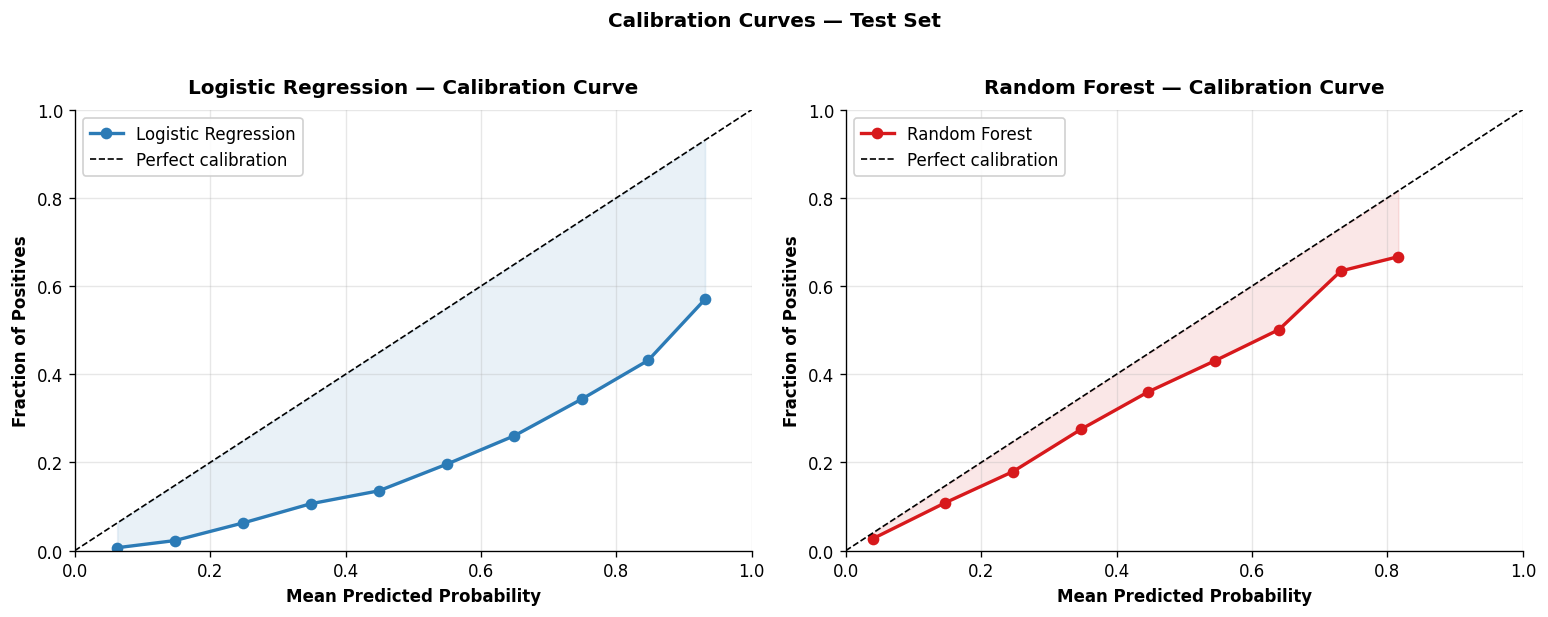

✓ Calibration curves saved


In [16]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Generate calibration curves: assesses reliability of predicted probabilities 

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, model) in zip(axes, results.items()):
    prob_true, prob_pred = calibration_curve(
        y_test, results[name]["y_prob"],
        n_bins=10, strategy="uniform"
    )
    ax.plot(
        prob_pred, prob_true,
        marker="o", linewidth=2,
        color=PALETTE["primary"] if name == "Logistic Regression" else PALETTE["secondary"],
        label=name
    )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.fill_between(prob_pred, prob_pred, prob_true, alpha=0.1,
                    color=PALETTE["primary"] if name == "Logistic Regression" else PALETTE["secondary"])
    ax.set_xlabel("Mean Predicted Probability", fontweight="bold")
    ax.set_ylabel("Fraction of Positives", fontweight="bold")
    ax.set_title(f"{name} — Calibration Curve", fontweight="bold", pad=10)
    ax.legend(framealpha=0.9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle("Calibration Curves — Test Set", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Calibration curves saved")


## 12) Classification Analysis: Per-Class Breakdown 

In [17]:
from sklearn.metrics import classification_report

# Output the per-class precision, recall and F1 score to provide a complete picture beyond only aggregate metrics

for name, res in results.items():
    print(f"── {name} ──────────────────────────────────────")
    print(classification_report(
        y_test, res["y_pred"],
        target_names=["No Diabetes", "Diabetes"],
        digits=4
    ))
    print()


── Logistic Regression ──────────────────────────────────────
              precision    recall  f1-score   support

 No Diabetes     0.9418    0.7154    0.8132     37970
    Diabetes     0.3164    0.7486    0.4448      6679

    accuracy                         0.7204     44649
   macro avg     0.6291    0.7320    0.6290     44649
weighted avg     0.8482    0.7204    0.7580     44649


── Random Forest ──────────────────────────────────────
              precision    recall  f1-score   support

 No Diabetes     0.8784    0.9496    0.9126     37970
    Diabetes     0.4689    0.2529    0.3286      6679

    accuracy                         0.8454     44649
   macro avg     0.6737    0.6013    0.6206     44649
weighted avg     0.8172    0.8454    0.8253     44649




## 13) Graphical Analyses: Exploratory

### 13.1) Class Distribution

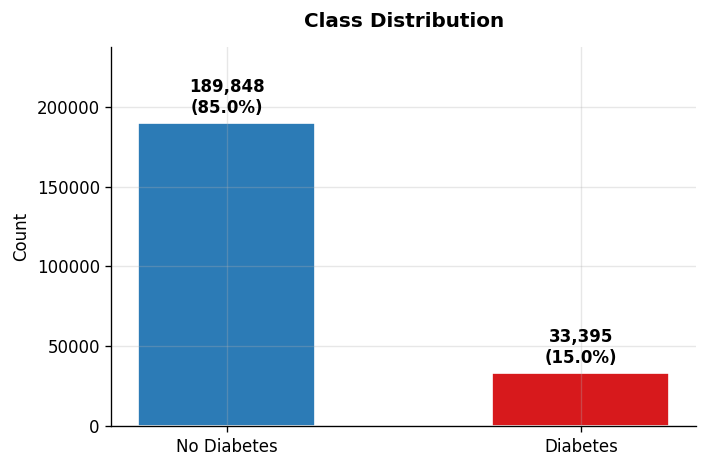

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = y.value_counts()
bars = ax.bar(
    ["No Diabetes", "Diabetes"], counts.values,
    color=[PALETTE["primary"], PALETTE["secondary"]],
    width=0.5, edgecolor="white"
)
for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.02,
        f"{count:,}\n({count/len(y):.1%})",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
ax.set_title("Class Distribution", fontweight="bold", pad=12)
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.25)
plt.tight_layout()
plt.savefig("outputs/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 13.2) Heatmap of Feature Correlations

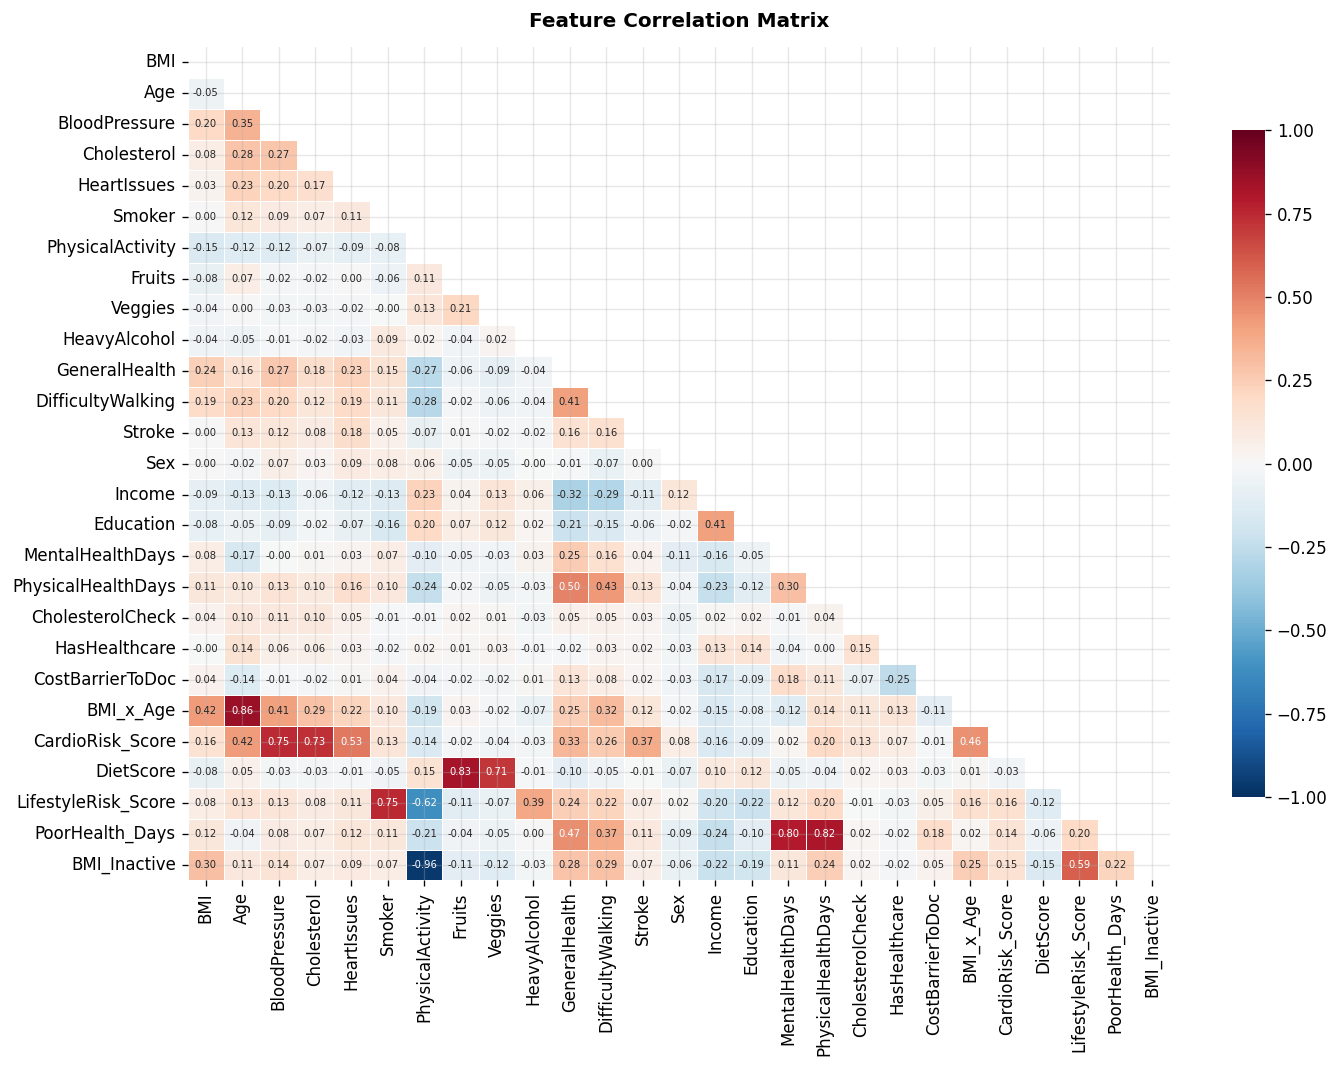

In [19]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={"size": 6},
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlation Matrix", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### 13.3) PCA Biplot

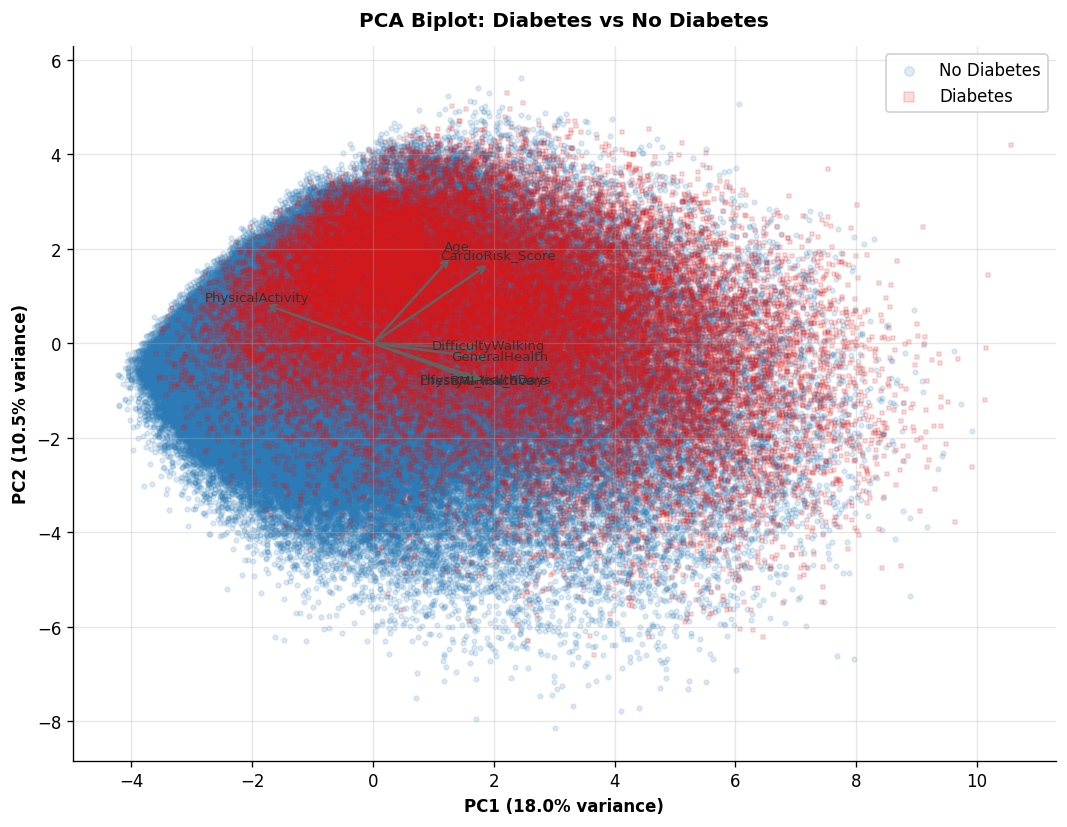

In [20]:
scaler_pca = StandardScaler()
X_scaled   = scaler_pca.fit_transform(X)
pca        = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca      = pca.fit_transform(X_scaled)
var_exp    = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 7))
for label, colour, marker, lname in [
    (0, PALETTE["primary"],   "o", "No Diabetes"),
    (1, PALETTE["secondary"], "s", "Diabetes"),
]:
    idx = y == label
    ax.scatter(
        X_pca[idx, 0], X_pca[idx, 1],
        c=colour, alpha=0.15, s=8, label=lname,
        marker=marker, rasterized=True
    )

# Loading arrows corresponding the 8 highest contributing features
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
top_idx  = np.argsort(np.abs(loadings).max(axis=1))[-8:]
for i in top_idx:
    ax.annotate(
        "", xy=(loadings[i,0]*3, loadings[i,1]*3), xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color=PALETTE["neutral"], lw=1.5)
    )
    ax.text(
        loadings[i,0]*3.2, loadings[i,1]*3.2,
        FEATURES_RENAMED[i], fontsize=8, ha="center", color="#333333"
    )

ax.set_xlabel(f"PC1 ({var_exp[0]:.1%} variance)", fontweight="bold")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1%} variance)", fontweight="bold")
ax.set_title("PCA Biplot: Diabetes vs No Diabetes", fontweight="bold", pad=12)
ax.legend(markerscale=2, framealpha=0.9)
plt.tight_layout()
plt.savefig("outputs/pca_biplot.png", dpi=150, bbox_inches="tight")
plt.show()


### 13.4) K-Means Clustering (PCA) 

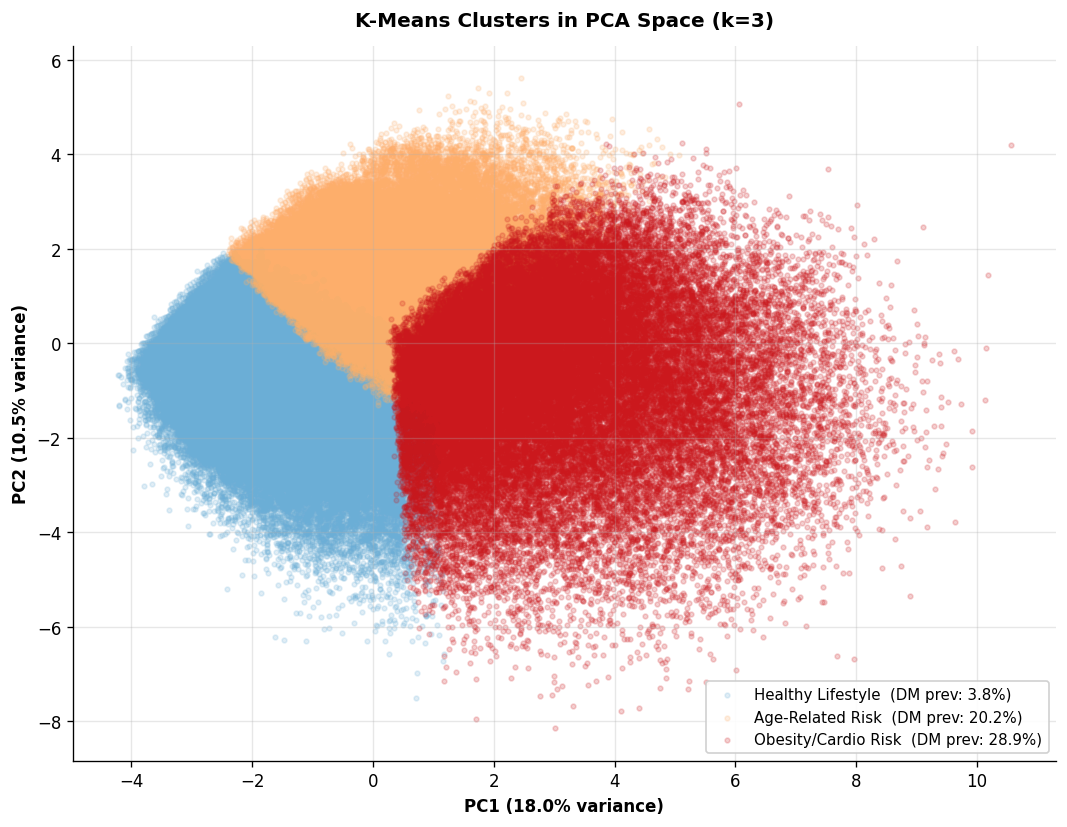

In [21]:
# k=3 clusters selected to map onto 3 clinically interpretable risk profiles
kmeans   = KMeans(n_clusters=3, random_state=RANDOM_SEED, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Label clusters by diabetes prevalence (ascending)
cluster_prev  = {c: y[clusters == c].mean() for c in range(3)}
sorted_c      = sorted(cluster_prev, key=cluster_prev.get)
label_map     = {
    sorted_c[0]: "Healthy Lifestyle",
    sorted_c[1]: "Age-Related Risk",
    sorted_c[2]: "Obesity/Cardio Risk",
}
cluster_colours = {
    "Healthy Lifestyle":  "#6BAED6",
    "Age-Related Risk":   "#FDAE6B",
    "Obesity/Cardio Risk":"#CB181D",
}

fig, ax = plt.subplots(figsize=(9, 7))
for cid, cname in label_map.items():
    idx = clusters == cid
    ax.scatter(
        X_pca[idx, 0], X_pca[idx, 1],
        c=cluster_colours[cname], alpha=0.2, s=8,
        label=f"{cname}  (DM prev: {cluster_prev[cid]:.1%})",
        rasterized=True
    )
ax.set_xlabel(f"PC1 ({var_exp[0]:.1%} variance)", fontweight="bold")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1%} variance)", fontweight="bold")
ax.set_title("K-Means Clusters in PCA Space (k=3)", fontweight="bold", pad=12)
ax.legend(framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.savefig("outputs/cluster_pca.png", dpi=150, bbox_inches="tight")
plt.show()


## 14) Graphical Analyses: Model Performance 

### 14.1) ROC Curves

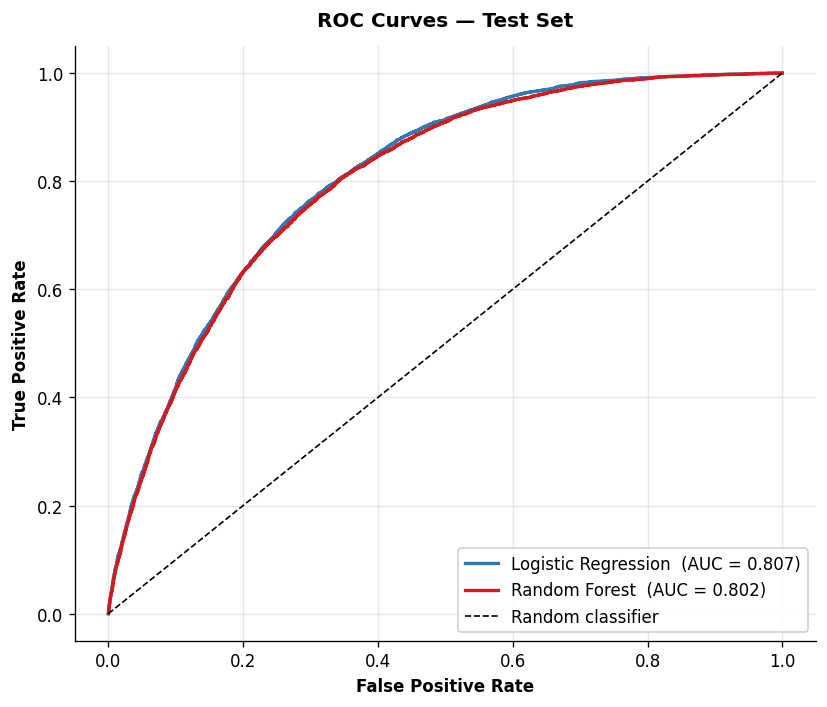

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, colour in [("Logistic Regression", PALETTE["primary"]),
                     ("Random Forest",       PALETTE["secondary"])]:
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_prob"])
    ax.plot(fpr, tpr, color=colour, lw=2,
            label=f"{name}  (AUC = {results[name]['auc_roc']:.3f})")

ax.plot([0,1],[0,1], "k--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontweight="bold")
ax.set_ylabel("True Positive Rate",  fontweight="bold")
ax.set_title("ROC Curves — Test Set", fontweight="bold", pad=12)
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig("outputs/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 14.2) Precision-Recall Curves

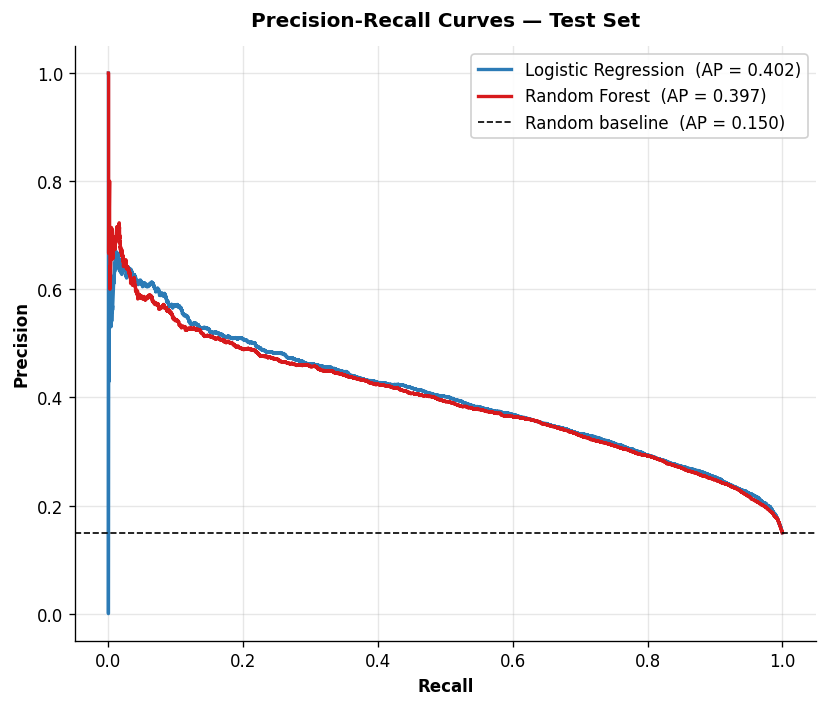

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, colour in [("Logistic Regression", PALETTE["primary"]),
                     ("Random Forest",       PALETTE["secondary"])]:
    prec, rec, _ = precision_recall_curve(y_test, results[name]["y_prob"])
    ax.plot(rec, prec, color=colour, lw=2,
            label=f"{name}  (AP = {results[name]['avg_prec']:.3f})")

baseline = y_test.mean()
ax.axhline(baseline, color="k", linestyle="--", lw=1,
           label=f"Random baseline  (AP = {baseline:.3f})")
ax.set_xlabel("Recall",    fontweight="bold")
ax.set_ylabel("Precision", fontweight="bold")
ax.set_title("Precision-Recall Curves — Test Set", fontweight="bold", pad=12)
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig("outputs/pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 14.3) Confusion Matrices

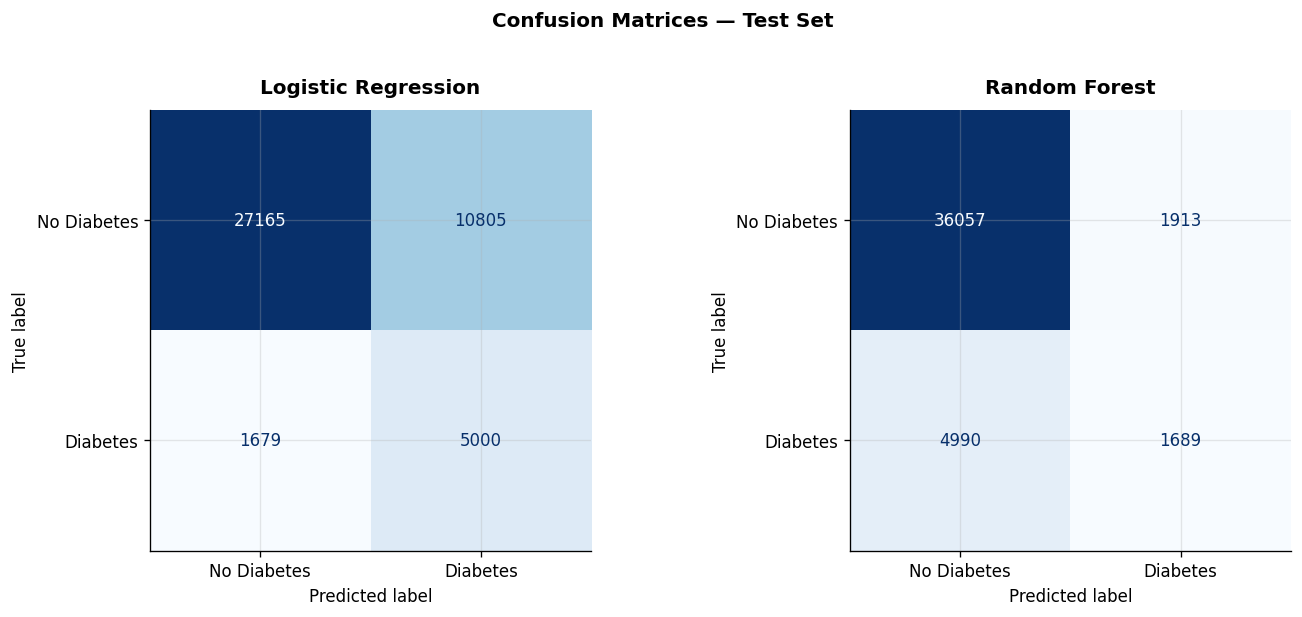

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Diabetes","Diabetes"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontweight="bold", pad=10)
plt.suptitle("Confusion Matrices — Test Set", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


### 14.4) Stability Boxplot

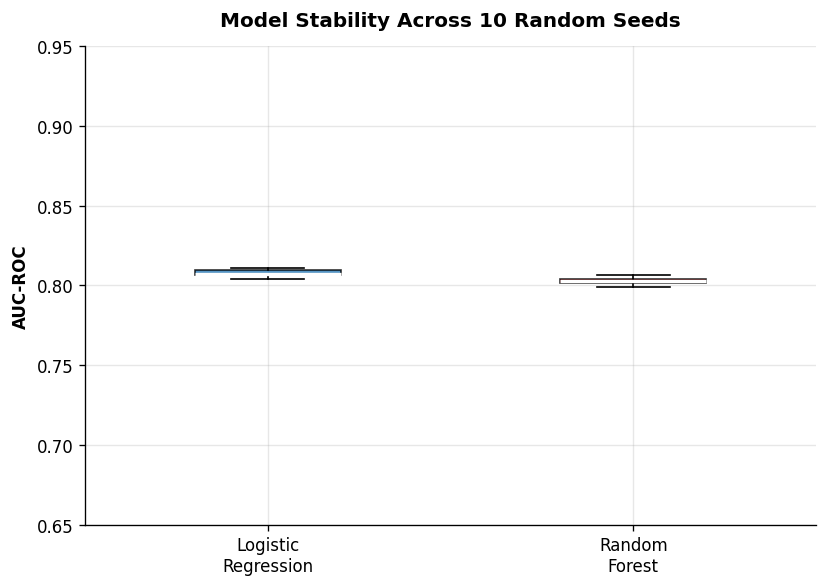

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(
    [stability["Logistic Regression"], stability["Random Forest"]],
    labels      = ["Logistic\nRegression", "Random\nForest"],
    patch_artist= True,
    medianprops = dict(color="white", linewidth=2),
    widths      = 0.4,
)
for patch, colour in zip(bp["boxes"], [PALETTE["primary"], PALETTE["secondary"]]):
    patch.set_facecolor(colour)
    patch.set_alpha(0.8)
ax.set_ylabel("AUC-ROC", fontweight="bold")
ax.set_title(f"Model Stability Across {N_SEEDS} Random Seeds",
             fontweight="bold", pad=12)
ax.set_ylim(0.65, 0.95)
plt.tight_layout()
plt.savefig("outputs/stability_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


## 15) Feature Importance and SHAP Analysis

### 15.1) Random Forest: Feature Importance Analysis (Mean Decrease Impurity)

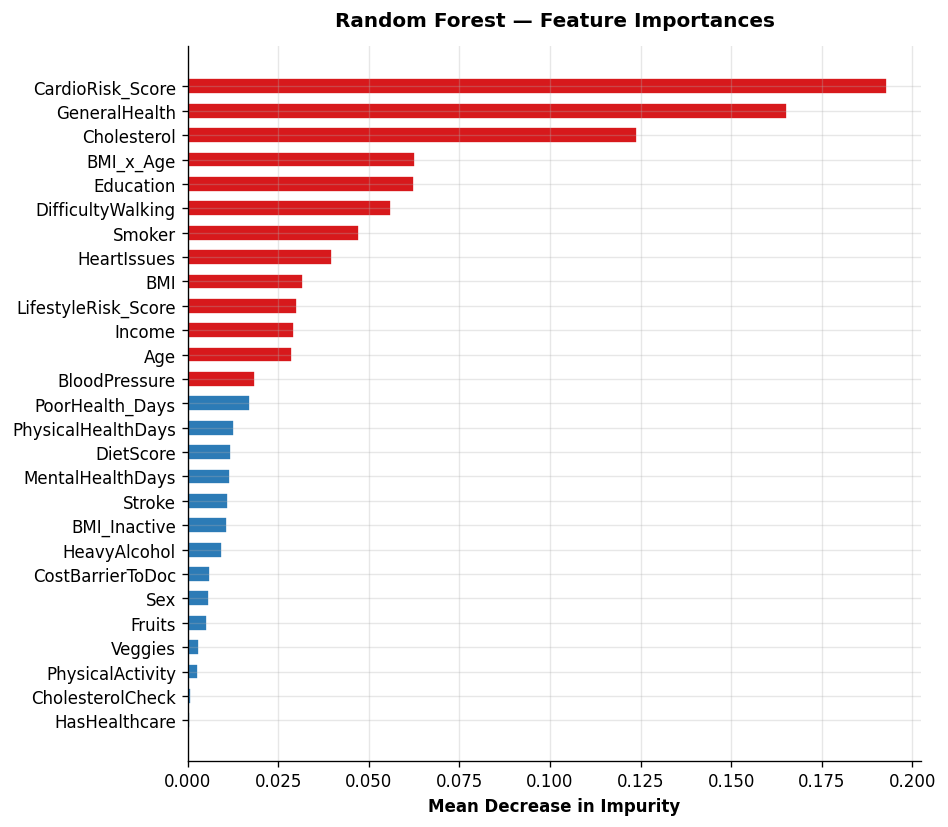

In [26]:
rf_fitted   = best_rf.named_steps["rf"]
feat_imp_df = pd.DataFrame({
    "Feature":    FEATURES_RENAMED,
    "Importance": rf_fitted.feature_importances_,
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    feat_imp_df["Feature"], feat_imp_df["Importance"],
    color=[PALETTE["secondary"] if v > feat_imp_df["Importance"].median()
           else PALETTE["primary"] for v in feat_imp_df["Importance"]],
    edgecolor="white", height=0.65
)
ax.set_xlabel("Mean Decrease in Impurity", fontweight="bold")
ax.set_title("Random Forest — Feature Importances", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("outputs/rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


### 15.2) Logistic Regression: Standardised Coefficients

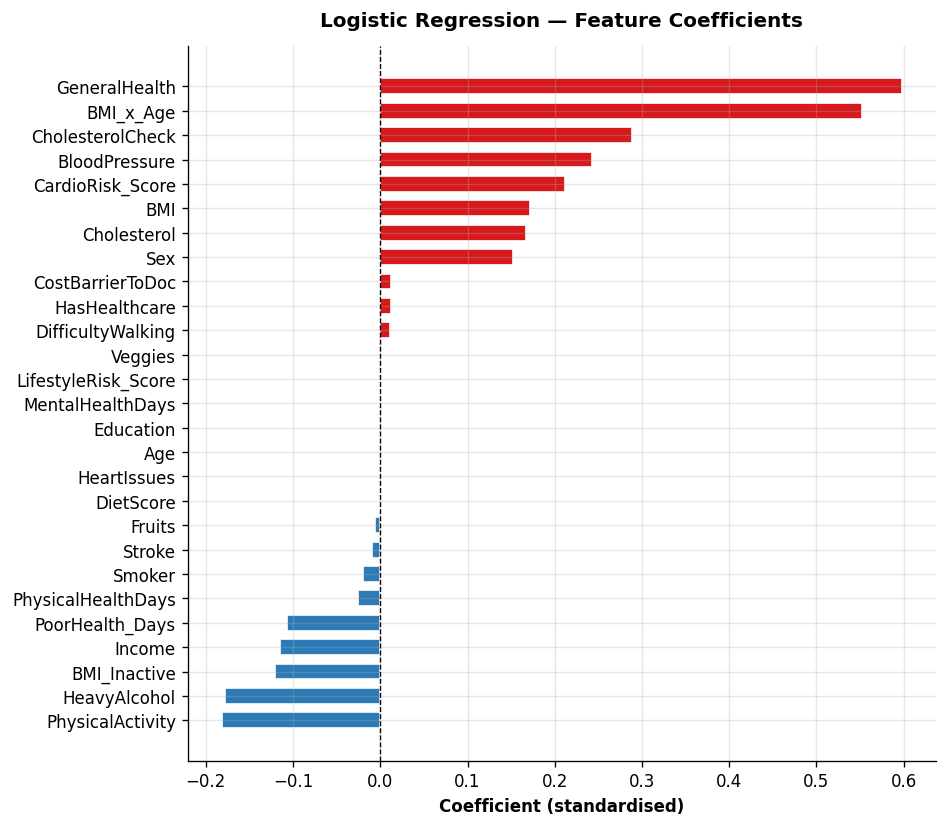

In [27]:
lr_fitted   = best_lr.named_steps["lr"]
lr_coef_df  = pd.DataFrame({
    "Feature":     FEATURES_RENAMED,
    "Coefficient": lr_fitted.coef_[0],
}).sort_values("Coefficient", ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    lr_coef_df["Feature"], lr_coef_df["Coefficient"],
    color=[PALETTE["secondary"] if v > 0 else PALETTE["primary"]
           for v in lr_coef_df["Coefficient"]],
    edgecolor="white", height=0.65
)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Coefficient (standardised)", fontweight="bold")
ax.set_title("Logistic Regression — Feature Coefficients", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("outputs/lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()


### 15.3) Random Forest: SHAP Analysis Summary

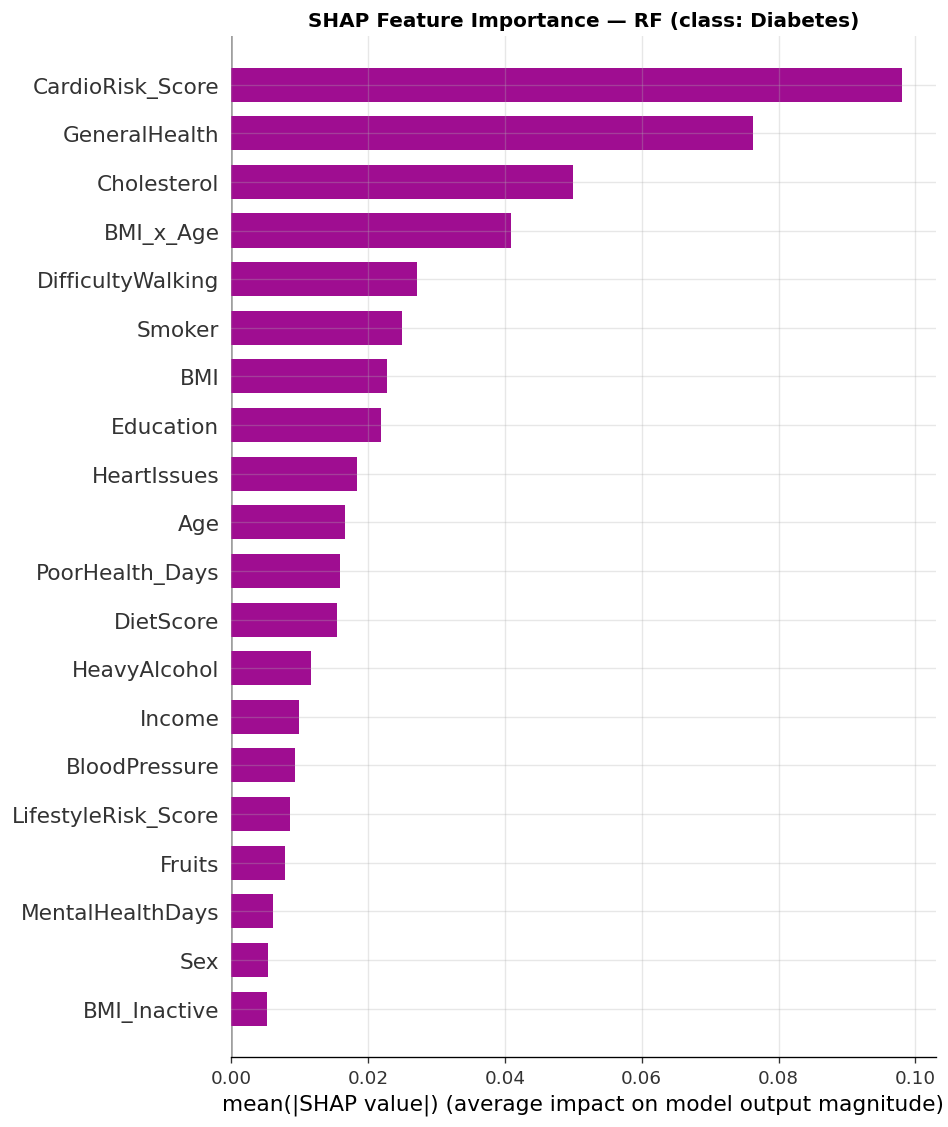

saved SHAP bar chart


In [28]:
# Sample 500 test rows (as opposed to full set, for time efficiency)
explainer   = shap.TreeExplainer(rf_fitted)
shap_sample = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_SEED)
shap_values = explainer.shap_values(shap_sample)

# Handle SHAP return-format change (due to it being a list in older versions but a 3-D array in newer versions).
# Extract class-1 (diabetes) values
# Positive SHAP results in push toward diabetes prediction
if isinstance(shap_values, list):
    shap_vals_pos = shap_values[1]
else:
    shap_vals_pos = (
        shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values
    )

fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    shap_vals_pos, shap_sample,
    plot_type    = "bar",
    feature_names= FEATURES_RENAMED,
    show         = False,
    color        = PALETTE["highlight"],
)
plt.title("SHAP Feature Importance — RF (class: Diabetes)", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved SHAP bar chart")


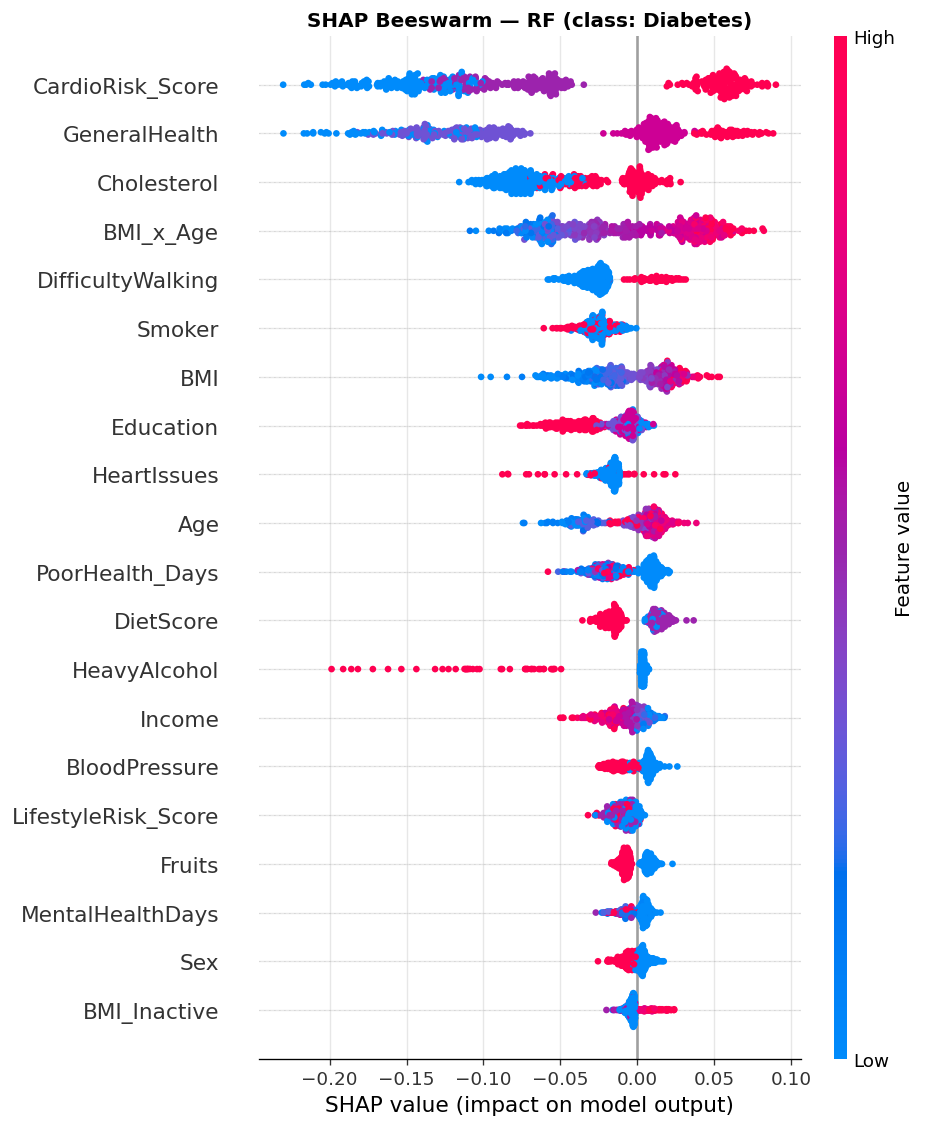

In [29]:
# Beeswarm plot: shows the effect in both magnitude and direction of each feature
fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    shap_vals_pos, shap_sample,
    feature_names= FEATURES_RENAMED,
    show         = False,
)
plt.title("SHAP Beeswarm — RF (class: Diabetes)", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()


## 16) Model Performance Comparison

In [30]:
summary_df = pd.DataFrame({
    "Metric": [
        "AUC-ROC", "F1 Score", "Precision", "Recall",
        "Accuracy", "Avg Precision",
        f"Stability mean (n={N_SEEDS})", f"Stability SD (n={N_SEEDS})"
    ],
    "Logistic Regression": [
        results["Logistic Regression"]["auc_roc"],
        results["Logistic Regression"]["f1"],
        results["Logistic Regression"]["precision"],
        results["Logistic Regression"]["recall"],
        results["Logistic Regression"]["accuracy"],
        results["Logistic Regression"]["avg_prec"],
        np.mean(stability["Logistic Regression"]),
        np.std(stability["Logistic Regression"]),
    ],
    "Random Forest": [
        results["Random Forest"]["auc_roc"],
        results["Random Forest"]["f1"],
        results["Random Forest"]["precision"],
        results["Random Forest"]["recall"],
        results["Random Forest"]["accuracy"],
        results["Random Forest"]["avg_prec"],
        np.mean(stability["Random Forest"]),
        np.std(stability["Random Forest"]),
    ],
}).set_index("Metric").round(4)

summary_df.to_csv("outputs/model_comparison.csv")
print("Saved to outputs/model_comparison.csv")
summary_df


Saved to outputs/model_comparison.csv


,Logistic Regression,Random Forest
Metric,,
AUC-ROC,0.8067,0.8022
F1 Score,0.4448,0.3286
Precision,0.3164,0.4689
Recall,0.7486,0.2529
Accuracy,0.7204,0.8454
Avg Precision,0.4022,0.3967
Stability mean (n=10),0.8075,0.8028
Stability SD (n=10),0.0020,0.0021


---
## Summary

| Aspect | Finding |
|--------|---------|
| **AUC-ROC** | LR 0.807 vs RF 0.802 — marginal LR lead |
| **Precision-recall trade-off** | LR favours recall (0.749); RF favours precision (0.469) |
| **Class imbalance** | Handled via SMOTE inside CV folds — no leakage |
| **Top features** | CardioRisk_Score, GeneralHealth, Cholesterol (SHAP + RF importance) |
| **Engineered features** | `CardioRisk_Score` ranked #1 in both importance analyses |
| **Stability** | Both models highly stable across 10 seeds (SD < 0.003) |


